In [15]:
import numpy as np    
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline    
from RENDES_fizinfo import *

In [16]:
# Gy / 10. feladat [16 p]
# 
# Egy teniszlabda átmérője 67 mm, tömege 58 g. 
# Ezt kézzel hajítjuk el 15 m/s nagyságú, 
# a vízszintessel 70°-os szöget bezáró irányban, 
# a talajtól 180 cm magasról indítva.
# 
# a) Ha nem ütközik akadályba, akkor hol, mikor és milyen sebességgel éri el a talajt? [4 p]
# 
# b) Mikor és hol lesz a labda gyorsulásának nagysága a legnagyobb, 
# és mennyi ennek a gyorsulásnak az értéke? [2 p]
# 
# c) Mikor és hol lesz a labda gyorsulásának nagysága épp g? [2 p]
# 
# d) Ha van előttünk 8 m-re egy magas fal, akkor azt hol éri el a labda? [2 p]
# 
# e) Milyen kezdőirányban kellene a labdát eldobnunk a többi paraméter megtartása mellett, 
# hogy az az előző pontbeli falon 4,5 m magasan levő kis ablakon épp berepüljön? 
# Több megoldás is van. [6 p]

In [17]:
# --- Teniszlabda fizikai paraméterei ---
m_ball = 0.058      # teniszlabda tömege [kg] = 58 g
d_ball = 0.067      # teniszlabda átmérője [m] = 67 mm
r_ball = d_ball / 2 # teniszlabda sugara [m]

A_ball = np.pi * r_ball**2  # keresztmetszeti felület [m^2]

C_ball = 0.55       # alaktényező / közegellenállási tényező [-]
rho_air = 1.225     # levegő sűrűsége normál körülmények között [kg/m^3]
g = 9.81            # gravitációs gyorsulás [m/s^2]

def create_grav_közeg_F_m(m, C, A, rho, g=9.81):
    """Egy konstans tömegű test tömege és a rá ható erő gravitációs tér és közegellenállás jelenlétében."""

    def mass_fun(t):   
        return m

    def force_fun(t, r, v, m):
        """Gravitációs erő y irányban és v^2-tel arányos közegellenállási erő eredője."""
        
        F_work=np.array([0.0, -m*g], np.float64) 
        v_abs=((v**2).sum())**0.5
        F_work-=0.5*C*A*rho*v*v_abs
    
        return F_work

    return force_fun, mass_fun

# --- Gravitáció + közegellenállás erőfüggvény létrehozása ---
F_ball, m_const_ball = create_grav_közeg_F_m(
    m=m_ball,       # test tömege [kg]
    C=C_ball,       # alaktényező [-]
    A=A_ball,       # keresztmetszeti felület [m^2]
    rho=rho_air,    # levegő sűrűsége [kg/m^3]
    g=g             # gravitációs gyorsulás [m/s^2]
)


# --- Kezdőfeltételek ---
kezdo_x = 0.0       # kezdeti x pozíció [m]
kezdo_y = 1.8       # kezdeti y pozíció [m] = 180 cm

indulo_sebesseg = 15.0   # kezdősebesség nagysága [m/s]
indulo_szog_fok = 70.0   # indulási szög a vízszintestől mérve [°]


# Sebességvektor felbontása x és y komponensre a szög alapján:
kezdo_vx = indulo_sebesseg * np.cos(np.radians(indulo_szog_fok))  # vízszintes sebesség [m/s]
kezdo_vy = indulo_sebesseg * np.sin(np.radians(indulo_szog_fok))  # függőleges sebesség [m/s]


# --- Egyszerű leállási feltétel: ha y < 0, akkor stop ---
def stop_ground_y(r, v):
    """Leállás y < 0 esetén."""
    
    return r[1] < 0.0


# --- Szimuláció előkészítése ---
ball_din = num_dinam(2)                    # 2D mozgás (x-y sík)
ball_din.set_time_range(0.0, 30.0, 0.001)  # t ∈ [0, 30] s, dt = 0.001 s

ball_din.set_F_fun(F_ball)                 # erőfüggvény: gravitáció + közegellenállás
ball_din.set_mass_fun(m_const_ball)        # konstans tömegfüggvény

ball_din.set_r0_v0(
    [kezdo_x, kezdo_y],                    # kezdeti helyzet [m]
    [kezdo_vx, kezdo_vy]                   # kezdeti sebesség [m/s]
)

ball_din.set_stop_cond(stop_ground_y)      # megállás, ha a labda eléri a talajt

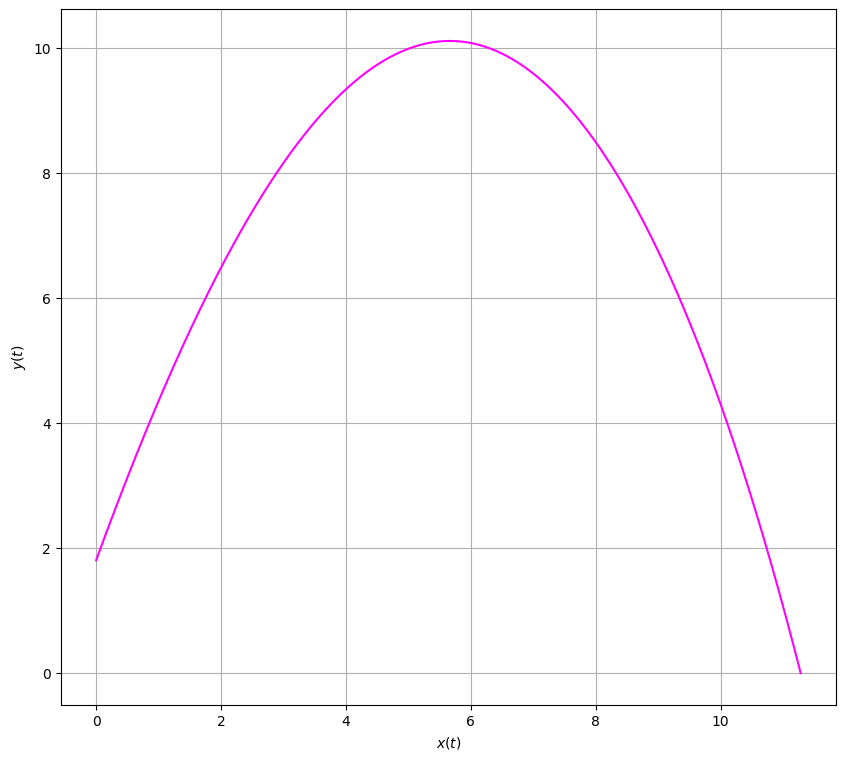

In [18]:
# --- Integráció futtatása ---
ball_din.full_dinam_calc()                 # numerikus integráció (pl. RK4)

# --- Pályagörbe megjelenítése ---
ball_din.plot_rcomp()                      # x(t) és y(t) komponensek külön ábrán


In [19]:
# a) Ha nem ütközik akadályba, akkor hol, mikor és milyen sebességgel éri el a talajt? [4 p]

elso_foldeteres = arg_eq(ball_din.r_y,0.00)[0]

print(f'A labda  {ball_din.r_x[elso_foldeteres]:.2f} m nél ér foldet')
print(f'A labda elosszor {ball_din.t[elso_foldeteres]:.2f} s nél ér foldet')
print(f'A labda sebessegel {ball_din.v_abs[elso_foldeteres]:.2f} m/s-el ér foldet')

A labda  11.28 m nél ér foldet
A labda elosszor 2.75 s nél ér foldet
A labda sebessegel 13.07 m/s-el ér foldet


In [20]:
# b) Mikor és hol lesz a labda gyorsulásának nagysága a legnagyobb, 
# és mennyi ennek a gyorsulásnak az értéke? [2 p]

max_gyorsulas_index = ball_din.a_abs.argmax()

print(f"Időpont: {ball_din.t[max_gyorsulas_index]:.4f} s")
print(f"x = {ball_din.r_x[max_gyorsulas_index]:.2f} m")
print(f"y = {ball_din.r_y[max_gyorsulas_index]:.2f} m")
print(f"a = {ball_din.a_abs[max_gyorsulas_index]:.2f} m/s²")


Időpont: 0.0000 s
x = 0.00 m
y = 1.80 m
a = 14.23 m/s²


In [21]:
# c) Mikor és hol lesz a labda gyorsulásának nagysága épp g? [2 p]
max_gyorsulas_index = arg_eq(ball_din.a_abs,9.81)[0]

print(f"Időpont: {ball_din.t[max_gyorsulas_index]:.4f} s")
print(f"x = {ball_din.r_x[max_gyorsulas_index]:.2f} m")
print(f"y = {ball_din.r_y[max_gyorsulas_index]:.2f} m")
print(f"a = {ball_din.a_abs[max_gyorsulas_index]:.2f} m/s²")

Időpont: 1.2640 s
x = 5.69 m
y = 10.12 m
a = 9.81 m/s²


In [22]:
# d) Ha van előttünk 8 m-re egy magas fal, akkor azt hol éri el a labda? [2 p]

print(f'Az elottünk évő falat y: {ball_din.y_values_at_x(8)[0]:.2f} m-nél éri el.')

Az elottünk évő falat y: 8.50 m-nél éri el.


In [23]:
# e) Milyen kezdőirányban kellene a labdát eldobnunk a többi paraméter megtartása mellett, 
# hogy az az előző pontbeli falon 4,5 m magasan levő kis ablakon épp berepüljön? 
# Több megoldás is van. [6 p]

# milyen szög hogy x=8-nál y=4,5 legyen?

def labda_szimulacio(szog_fok, dt=0.01, t_max=100.0):
    # A kezdősebesség nagysága minden szögnél ugyanaz, csak az x-y komponensek változnak.
    vx0 = indulo_sebesseg * np.cos(np.radians(szog_fok))
    vy0 = indulo_sebesseg * np.sin(np.radians(szog_fok))
    
    # Minden szöghöz új objektumot készítünk, hogy a korábbi futások ne keveredjenek bele.
    ball_szim = num_dinam(2)
    ball_szim.set_time_range(0.0, t_max, dt)
    ball_szim.set_F_fun(F_ball)
    ball_szim.set_mass_fun(m_const_ball)
    ball_szim.set_r0_v0([kezdo_x, kezdo_y], [vx0, vy0])
    ball_szim.stop_cond = stop_ground_y
    
    # Teljes dinamikai számítás a becsapódásig.
    ball_szim.full_dinam_calc()
    
    return ball_szim

# A lehetséges kezdőszögeket végigpróbáljuk 0° és 90° között.
# Itt 0.01°-os lépésközt használunk, ezért a kapott eredmény már elég pontos közelítés.
szogek = np.arange(0.0, 90.0 + 0.01, 0.01)


fal_x = 8.0      # a fal vízszintes távolsága az eldobás helyétől [m]
ablak_y = 4.5    # az ablak / célmagasság [m]

# Ezekben tároljuk az előző vizsgált szöget és az ahhoz tartozó hibát.
# A "hiba" azt jelenti, hogy x = 8 m-nél mennyivel van a labda
# az ablak magassága felett vagy alatt.
elozo_szog = None
elozo_hiba = None


for szog in szogek:
    # Lefuttatjuk a labda mozgását az aktuális kezdőszöggel.
    # A kezdősebesség nagysága ugyanaz marad, csak az iránya változik.
    ball_szim = labda_szimulacio(szog)
    
    
    # Megnézzük, hogy az aktuális pálya milyen y magasságban metszi
    # az x = 8 m függőleges egyenest, vagyis a fal helyét.
    y_ertekek = ball_szim.y_values_at_x(fal_x)
    
    
    # Ha az y_ertekek üres, akkor a labda ennél a szögnél
    # nem jutott el az x = 8 m helyig.
    # Ilyenkor nincs mit összehasonlítani, ezért továbblépünk.
    if len(y_ertekek) == 0:
        continue
    
    
    # Az x = 8 m-nél kapott magasság.
    # Normál hajításnál itt általában egyetlen metszéspont lesz.
    aktualis_y = y_ertekek[0]
    
    
    # A hiba azt mutatja meg, hogy a labda az ablakhoz képest hol halad el:
    #
    # aktualis_hiba > 0  → a labda az ablak fölött megy el
    # aktualis_hiba < 0  → a labda az ablak alatt megy el
    # aktualis_hiba = 0  → a labda pontosan az ablak magasságában van
    aktualis_hiba = aktualis_y - ablak_y
    
    
    # Ha már van előző vizsgált szögünk, akkor össze tudjuk hasonlítani
    # az előző hibát és a mostani hibát.
    #
    # Ha a két hiba szorzata negatív, akkor az egyik hiba pozitív,
    # a másik negatív volt.
    #
    # Ez azt jelenti, hogy a két szög között valahol át kellett mennie
    # a labdának pontosan az y = 4.5 m magasságon.
    if elozo_hiba is not None:
        if elozo_hiba * aktualis_hiba < 0:
            
            # Egyszerű közelítésként a két szög közepét vesszük.
            # Ez nem tökéletes gyökkeresés, de a 0.01°-os lépés miatt
            # már elég jó közelítést ad.
            megoldas_szog = (elozo_szog + szog) / 2
            
            print(f'A labda kb. {megoldas_szog:.2f}° kezdőszögnél repül be az ablakon.')
    
    
    # A ciklus végén eltároljuk a mostani szöget és hibát,
    # hogy a következő körben ezek legyenek az "előző" értékek.
    elozo_szog = szog
    elozo_hiba = aktualis_hiba




A labda kb. 31.59° kezdőszögnél repül be az ablakon.
A labda kb. 74.44° kezdőszögnél repül be az ablakon.


In [24]:
szogek = np.arange(0.0, 90.0 + 0.01, 0.01)


for szog in szogek:
    ball_szim = labda_szimulacio(szog)

    if ball_szim.passes_near_y_at_x(fal_x,ablak_y,0.01):
        print(f'talalt szog: {szog:.2f}°')

talalt szog: 31.53°
talalt szog: 31.54°
talalt szog: 31.55°
talalt szog: 31.56°
talalt szog: 31.57°
talalt szog: 31.58°
talalt szog: 31.59°
talalt szog: 31.60°
talalt szog: 31.61°
talalt szog: 31.62°
talalt szog: 31.63°
talalt szog: 31.64°
talalt szog: 31.65°
talalt szog: 31.66°
talalt szog: 74.44°
